## Реализуем аналитическую модель из [Flexural wave band gaps in locally resonant thin plates with periodically attached spring--mass resonators](https://iopscience.iop.org/article/10.1088/0022-3727/45/19/195401)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import eigh
from tqdm import tqdm

### Базовые параметры были взяты из статьи

In [77]:
base_params = {
    "E": 70e9,
    "nu": 0.3,
    "rho": 2700,
    "h": 0.002,
    "a": 0.1,
    "mR": 0.027,
    "fR_target": 300
}


def get_dispersion_plot(E = 70e9, nu = 0.3, rho = 2700, h = 0.002, a = 0.1, mR = 0.027, fR_target = 300, f_low=None, f_high=None, M_order=11):
    kR = mR * (2 * np.pi * fR_target) ** 2 

    D_const = (E * h ** 3) / (12 * (1 - nu ** 2))
    S = a**2          
    mass_plate = rho * h * S

    range_M = np.arange(-M_order, M_order + 1)
    GX, GY = np.meshgrid(range_M, range_M)
    GX, GY = GX.flatten() * (2 * np.pi / a), GY.flatten() * (2 * np.pi / a)
    N_waves = len(GX)

    pts = 40
    path_k = np.zeros((3 * pts, 2))
    path_k[0:pts, 0] = np.linspace(0, np.pi/a, pts)
    path_k[pts:2*pts, 0] = np.pi/a                 
    path_k[pts:2*pts, 1] = np.linspace(0, np.pi/a, pts)
    path_k[2*pts:, 0] = np.linspace(np.pi/a, 0, pts)
    path_k[2*pts:, 1] = np.linspace(np.pi/a, 0, pts)

    freqs_lr = []
    freqs_bare = []

    for kx, ky in path_k:
        K_diag = ((kx + GX) ** 2 + (ky + GY) ** 2) ** 2
        K_mat = np.diag(K_diag)
        
        U = np.ones((N_waves, N_waves))
        I = np.eye(N_waves)

        LHS_b = D_const * S * K_mat
        RHS_b = mass_plate * I
        vals_b, _ = eigh(LHS_b, RHS_b)
        freqs_bare.append(np.sqrt(np.maximum(vals_b, 0)) / (2 * np.pi))

        A = np.zeros((N_waves + 1, N_waves + 1))
        A[:N_waves, :N_waves] = D_const * S * K_mat + kR * U
        A[:N_waves, N_waves] = -kR * np.ones(N_waves)
        A[N_waves, :N_waves] = -kR * np.ones(N_waves)
        A[N_waves, N_waves] = kR
        
        B = np.zeros((N_waves + 1, N_waves + 1))
        B[:N_waves, :N_waves] = mass_plate * I
        B[N_waves, N_waves] = mR
        
        vals_lr, _ = eigh(A, B)
        freqs_lr.append(np.sqrt(np.maximum(vals_lr, 0)) / (2 * np.pi))

    freqs_lr = np.array(freqs_lr)
    freqs_bare = np.array(freqs_bare)

    plt.figure(figsize=(10, 7))

    for i in range(8):
        label = 'Bare plate' if i == 0 else ""
        plt.scatter(range(len(path_k)), freqs_bare[:, i], color='blue', s=2, alpha=0.5, label=label)

    for i in range(8):
        label = 'LR plate' if i == 0 else ""
        plt.plot(freqs_lr[:, i], color='black', linewidth=1.5, label=label)

    plt.xlim(0, len(path_k)-1)
    plt.ylim(0, 800)
    plt.ylabel('Frequency (Hz)', fontsize=14)
    plt.title(f'Band Structure (f_R = {fR_target} Hz)', fontsize=16)

    plt.axvline(pts, color='gray', linestyle='--')
    plt.axvline(2 * pts, color='gray', linestyle='--')
    plt.xticks([0, pts, 2 * pts, 3 * pts - 1], [r'$\Gamma$', 'X', 'M', r'$\Gamma$'], fontsize=14)

    if f_low is not None:
        plt.axhline(f_low, color="red", linestyle="--", linewidth=1.5)

    if f_high is not None:
        plt.axhline(f_high, color="red", linestyle="--", linewidth=1.5, label="band gap")

    plt.legend(loc='upper right')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [58]:
def find_band_gaps(freqs, k_slice=None, fmin=None, fmax=None, min_width=1e-6):
    arr = freqs if k_slice is None else freqs[k_slice]

    band_mins = np.min(arr, axis=0)
    band_maxs = np.max(arr, axis=0)

    gaps = []
    for i in range(arr.shape[1] - 1):
        low = band_maxs[i]
        high = band_mins[i + 1]
        width = high - low

        if width > min_width:
            low_clip = max(low, fmin) if fmin is not None else low
            high_clip = min(high, fmax) if fmax is not None else high

            if high_clip - low_clip > min_width:
                gaps.append({
                    "band_left": i,
                    "band_right": i + 1,
                    "f_low": float(low_clip),
                    "f_high": float(high_clip),
                    "width": float(high_clip - low_clip),
                })

    gaps.sort(key=lambda g: g["width"], reverse=True)
    return gaps

In [78]:
def get_band_gap(E = 70e9, nu = 0.3, rho = 2700, h = 0.002, a = 0.1, mR = 0.027, fR_target = 300, M_order=11):
    kR = mR * (2 * np.pi * fR_target)**2 

    D_const = (E * h**3) / (12 * (1 - nu**2))
    S = a**2          
    mass_plate = rho * h * S

    range_M = np.arange(-M_order, M_order + 1)
    GX, GY = np.meshgrid(range_M, range_M)
    GX, GY = GX.flatten() * (2 * np.pi / a), GY.flatten() * (2 * np.pi / a)
    N_waves = len(GX)

    
    pts = 40
    path_k = np.zeros((3 * pts, 2))
    path_k[0:pts, 0] = np.linspace(0, np.pi/a, pts)
    path_k[pts:2*pts, 0] = np.pi/a
    path_k[pts:2*pts, 1] = np.linspace(0, np.pi/a, pts)
    path_k[2*pts:, 0] = np.linspace(np.pi/a, 0, pts)
    path_k[2*pts:, 1] = np.linspace(np.pi/a, 0, pts)

    freqs_lr = []
    freqs_bare = []

    for kx, ky in path_k:
        K_diag = ((kx + GX)**2 + (ky + GY)**2)**2
        K_mat = np.diag(K_diag)
    
        U = np.ones((N_waves, N_waves))
        I = np.eye(N_waves)

        LHS_b = D_const * S * K_mat
        RHS_b = mass_plate * I
        vals_b, _ = eigh(LHS_b, RHS_b)
        freqs_bare.append(np.sqrt(np.maximum(vals_b, 0)) / (2 * np.pi))

        A = np.zeros((N_waves + 1, N_waves + 1))
        A[:N_waves, :N_waves] = D_const * S * K_mat + kR * U
        A[:N_waves, N_waves] = -kR * np.ones(N_waves)
        A[N_waves, :N_waves] = -kR * np.ones(N_waves)
        A[N_waves, N_waves] = kR
        
        B = np.zeros((N_waves + 1, N_waves + 1))
        B[:N_waves, :N_waves] = mass_plate * I
        B[N_waves, N_waves] = mR
        
        vals_lr, _ = eigh(A, B)
        freqs_lr.append(np.sqrt(np.maximum(vals_lr, 0)) / (2 * np.pi))

    freqs_lr = np.array(freqs_lr)
    freqs_bare = np.array(freqs_bare)

    gaps_all = find_band_gaps(freqs_lr, fmin=0, fmax=800)

    return gaps_all

### Проверим поиск запрещенных зон на базовых параметрах

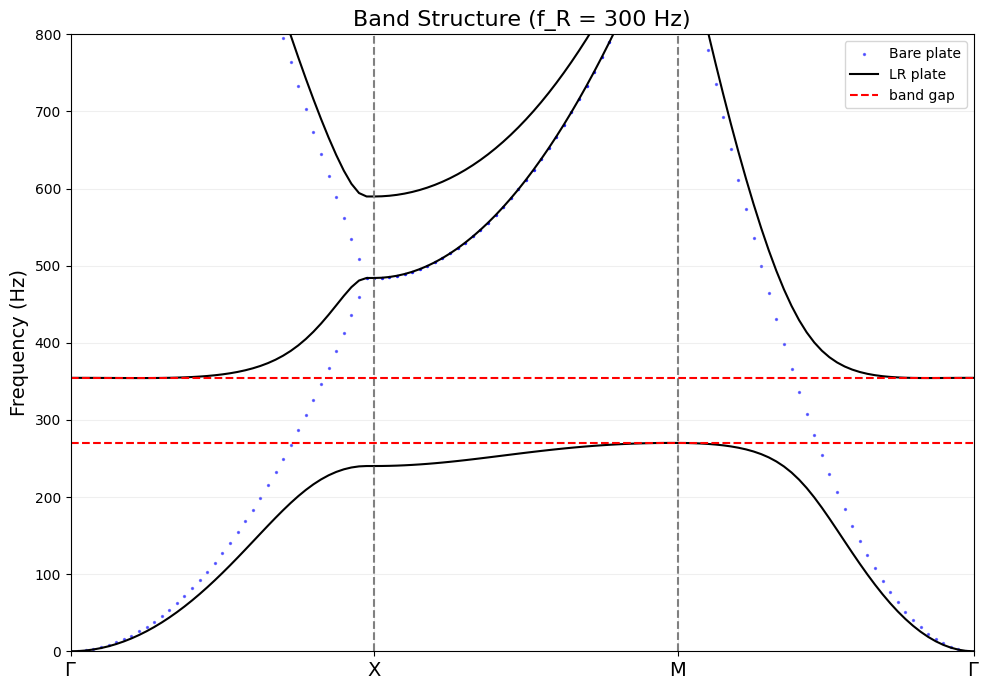

,band_left,band_right,f_low,f_high,width
0,0,1,270.166041,354.282324,84.116283


In [79]:
gaps = get_band_gap(**base_params)
gap = gaps[0]
get_dispersion_plot(**base_params, f_low=gap["f_low"], f_high=gap["f_high"])
pd.DataFrame(gaps)


### У нас есть параметр M_order, отвечающий за количество волн. Давайте посмотрим какого значения нам хватит для достаточной точности.

In [ ]:
Ms = tqdm(range(1, 20, 2))
results = []

for M in Ms:
    results.append(get_band_gap(M_order=M)[0])

df = pd.DataFrame(results)
df["M"] = Ms
df

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [02:39<00:00, 15.99s/it]


,band_left,band_right,f_low,f_high,width,M
0,0,1,271.964493,356.298520,84.334027,1
1,0,1,270.425342,354.648919,84.223577,3
2,0,1,270.252979,354.409898,84.156918,5
3,0,1,270.200579,354.333624,84.133044,7
4,0,1,270.177892,354.300021,84.122129,9
5,0,1,270.166041,354.282324,84.116283,11
6,0,1,270.159077,354.271877,84.112800,13
7,0,1,270.154638,354.265201,84.110562,15
8,0,1,270.151637,354.260677,84.109041,17
9,0,1,270.149512,354.257472,84.107960,19


### Учитывая время работы, думаю что оптимальный M_order - 5